# 공통 · 데이터 계약과 버전 저장소

공유 정의를 보관하는 모듈입니다. `pipeline_library` 태그 셀만 다른 노트북에서 로드합니다.
학습·배치 처리를 자동 실행하지 않습니다. JSON 상태는 단일 writer 잠금과 원자적 교체로 기록합니다.
로컬 파일 기반 구현이며 여러 서버의 분산 운영·DB 트랜잭션·인증 서버는 범위 밖입니다.


In [ ]:
from pathlib import Path
from contextlib import contextmanager
from datetime import datetime, timezone
import hashlib, json, os, re, uuid, platform
import numpy as np
import pandas as pd
import joblib
import sklearn



In [ ]:
def now_utc():
    return datetime.now(timezone.utc).isoformat()



In [ ]:
def sha256(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()



In [ ]:
def atomic_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    temporary = path.with_name(path.name + '.' + uuid.uuid4().hex + '.tmp')
    temporary.write_text(json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False), encoding='utf-8')
    os.replace(temporary, path)



In [ ]:
def read_json(path, default=None):
    return json.loads(Path(path).read_text(encoding='utf-8')) if Path(path).exists() else default



In [ ]:
def safe_id(value):
    if not isinstance(value, str) or not re.fullmatch(r'[A-Za-z0-9][A-Za-z0-9_.-]{0,100}', value):
        raise ValueError('ID는 영문·숫자·밑줄·점·하이픈 1~101자로 지정하세요.')
    return value



In [ ]:
def load_library(path, namespace):
    """프로젝트 노트북의 명시적으로 태그된 정의 셀만 로드. 실행/학습 셀 제외."""
    notebook = read_json(path)
    for index, cell in enumerate(notebook['cells']):
        if cell['cell_type'] == 'code' and 'pipeline_library' in cell.get('metadata', {}).get('tags', []):
            exec(compile(''.join(cell['source']), f'{path}:cell-{index}', 'exec'), namespace)
    return namespace



In [ ]:
class Pipeline:
    """CN7/RG3별 독립 로컬 상태. output은 삭제 가능, runtime은 운영 상태이므로 보존."""
    def __init__(self, root, dataset, state_root=None):
        if dataset not in {'cn7', 'rg3'}:
            raise ValueError('dataset은 cn7 또는 rg3')
        self.root, self.dataset = Path(root).resolve(), dataset
        self.state = (Path(state_root) if state_root else self.root/'runtime') / dataset
        self.output = self.root/'output/pipeline' if state_root is None else Path(state_root)/'reports'
        self.features = read_json(self.root/'data/schema/input_features.json')['feature_columns']
        self.schema_hash = sha256(self.root/'data/schema/input_features.json')
        self.coordinate_id = f'{dataset}:provided_labeled_coordinates:v1'
        self.code = load_library(self.root/'03.modeling/models/ocsvm.ipynb', {'__name__': '__pipeline_library__'})
        self.code.update(ROOT=self.root, DATASET=dataset, NOTEBOOK_PATH=self.root/'03.modeling/models/ocsvm.ipynb')

    @contextmanager
    def lock(self):
        self.state.mkdir(parents=True, exist_ok=True)
        lock = self.state/'.writer.lock'
        descriptor = os.open(lock, os.O_CREAT | os.O_EXCL | os.O_WRONLY)
        try:
            os.write(descriptor, str(os.getpid()).encode())
            yield
        finally:
            os.close(descriptor)
            lock.unlink()

    def data(self):
        return self.code['load_data'](self.root)

    def validate_x(self, frame):
        if list(frame.columns) != self.features:
            raise ValueError('입력 24개 컬럼과 순서가 스키마와 다릅니다.')
        if frame.empty or not all(pd.api.types.is_numeric_dtype(t) for t in frame.dtypes):
            raise ValueError('비어 있거나 수치형이 아닌 입력입니다.')
        if not np.isfinite(frame.to_numpy(dtype=float)).all():
            raise ValueError('결측·무한값 입력은 보류합니다.')
        return frame.astype(float)

    def fingerprints(self, frame):
        values = self.validate_x(frame).to_numpy(dtype='<f8', copy=True)
        values[values == 0.] = 0.  # -0.0과 0.0은 동일 패턴
        return [hashlib.sha256(row.tobytes()).hexdigest() for row in values]

    def pointer(self):
        return read_json(self.state/'registry.json', {'active_ocsvm': None, 'fixed_if': None, 'history': []})

    def save_model(self, kind, bundle, metadata):
        version = f'{kind}-{uuid.uuid4().hex[:16]}'
        folder = self.state/'models'/version
        folder.mkdir(parents=True, exist_ok=False)
        bundle.update(dataset=self.dataset, schema_hash=self.schema_hash, coordinate_id=self.coordinate_id)
        joblib.dump(bundle, folder/'model.joblib')
        record = dict(metadata, version=version, kind=kind, dataset=self.dataset,
                      schema_hash=self.schema_hash, coordinate_id=self.coordinate_id,
                      created_at=now_utc(), artifact_sha256=sha256(folder/'model.joblib'),
                      python=platform.python_version(), sklearn=sklearn.__version__)
        atomic_json(folder/'manifest.json', record)
        return version

    def model(self, version, kind=None):
        folder = self.state/'models'/safe_id(version)
        record = read_json(folder/'manifest.json')
        if not record or record['dataset'] != self.dataset or record['schema_hash'] != self.schema_hash:
            raise ValueError('모델 데이터셋/스키마 불일치')
        if kind and record['kind'] != kind:
            raise ValueError('모델 종류 불일치')
        if sha256(folder/'model.joblib') != record['artifact_sha256']:
            raise ValueError('모델 파일 해시 불일치')
        if record['sklearn'] != sklearn.__version__:
            raise ValueError('저장 모델과 실행 환경의 scikit-learn 버전이 다릅니다.')
        return joblib.load(folder/'model.joblib'), record

    def base_corpus(self):
        x, y, assignment, dev, test, _ = self.data()
        frame = x.loc[dev].copy()
        frame['label'] = y.loc[dev].to_numpy()
        frame['fingerprint'] = self.fingerprints(x.loc[dev])
        frame['source'] = assignment.loc[dev, 'pattern_id'].to_numpy()
        return frame.reset_index(drop=True)

    def predict_ocsvm(self, version, x):
        bundle, _ = self.model(version, 'ocsvm')
        return self.code['predict_artifact'](bundle, self.validate_x(x))



In [ ]:
def register_ocsvm_baseline(ctx, artifact_path):
    """Bind registration to the audited artifact, data, split, and source code."""
    artifact_path = Path(artifact_path)
    folder = artifact_path.parent
    run = read_json(folder/'run_config.json')
    audit = read_json(folder/'postrun_audit.json')
    verification = read_json(folder/'verification.json')
    selection = read_json(folder/'selection_manifest.json')
    if not run or run.get('dataset') != ctx.dataset or not audit or not audit.get('passed'):
        raise ValueError('데이터셋별 전체 학습·감사를 먼저 완료하세요.')
    if not verification or not selection:
        raise ValueError('모델·선택 검증 기록이 없습니다.')
    approved = verification.get('artifact_sha256', {})
    for required in [artifact_path.name, 'run_config.json', 'selection_manifest.json']:
        if required not in approved:
            raise ValueError('감사에서 필수 산출물 해시가 누락됐습니다: '+required)
    for name, expected in approved.items():
        target = (folder/name).resolve()
        if target.parent != folder.resolve() or not target.is_file() or sha256(target) != expected:
            raise ValueError('검증 이후 산출물이 변경됐습니다: '+name)
    _, _, _, _, _, current = ctx.data()
    split_path = ctx.root/f'data/processed/{ctx.dataset}/conservative/splits/split_assignments.csv'
    if run.get('source_sha256') != current['source_sha256'] or run.get('split_sha256') != sha256(split_path):
        raise ValueError('검증 당시 데이터·분할과 현재 데이터가 다릅니다.')
    if run.get('notebook_code_sha256') != ctx.code['notebook_code_digest']():
        raise ValueError('검증 이후 모델링 코드가 변경됐습니다.')
    artifact = joblib.load(artifact_path)
    if artifact.get('selection_sha256') != sha256(folder/'selection_manifest.json'):
        raise ValueError('모델과 선택 기록이 다릅니다.')
    choices=selection.get('choices', [])
    if len(choices)!=1 or artifact.get('choice')!=choices[0] or artifact.get('threshold')!=choices[0].get('threshold'):
        raise ValueError('모델 설정·임계값과 검증된 선택이 다릅니다.')
    if artifact['features']['input_columns'] != ctx.features:
        raise ValueError('모델 입력 열 계약이 다릅니다.')
    artifact.update(corpus=ctx.base_corpus(), train_record_ids=[], parent=None)
    with ctx.lock():
        source_hash=sha256(artifact_path)
        for path in (ctx.state/'models').glob('*/manifest.json'):
            existing=read_json(path)
            if existing.get('status')=='baseline_candidate' and existing.get('source_artifact_sha256')==source_hash:
                ctx.model(existing['version'],'ocsvm')
                return existing['version']
        version=ctx.save_model('ocsvm', artifact, dict(status='baseline_candidate', parent=None,
            source_artifact_sha256=source_hash, train_record_ids=[],
            source_run=str(folder), data_sha256=run['source_sha256'], split_sha256=run['split_sha256'],
            notebook_code_sha256=run['notebook_code_sha256'],
            evidence={name:read_json(folder/name) for name in ['run_config.json','selection_manifest.json','verification.json','postrun_audit.json']},
            choice=artifact['choice'], scope='normal-only fit; observed Test follow-up'))
        return version


In [ ]:
def metrics(truth, prediction):
    y, p = np.asarray(truth), np.asarray(prediction)
    tp, fn = int(((y==1)&(p==1)).sum()), int(((y==1)&(p==0)).sum())
    fp, tn = int(((y==0)&(p==1)).sum()), int(((y==0)&(p==0)).sum())
    return dict(TP=tp, FN=fn, FP=fp, TN=tn, recall=tp/(tp+fn) if tp+fn else None,
                FPR=fp/(fp+tn) if fp+tn else None,
                precision=tp/(tp+fp) if tp+fp else 0., F1=2*tp/(2*tp+fp+fn) if 2*tp+fp+fn else 0.)


## 결과보고서 v4 시각화

아래 셀만 실행하면 이 노트북에 해당하는 보고서 그림을 표시한다. 기존 학습·전처리·운영 셀을 다시 실행할 필요가 없다.
공통 생성 코드는 `reporting/visualizations.py`에 있다. 그림이 없으면 해당 코드를 먼저 실행한다.
고정 Test는 이미 관찰한 후속 평가이며, RF 연구 v1과 표준화 수정 후 v2를 구분한다.
시각화용 중앙값·IQR 변환은 표시 목적에 한정되며 모델 입력이나 기존 표준화 로직을 변경하지 않는다.


### 입력 계약과 패턴·원본 연결

현행 공통 코드와 저장 계약 / 절차도 / 성능 결과 아님

패턴 학습과 원본 관측치 검사 평가를 연결하였다. 품질 라벨, 원본 ID와 빈도는 예측 입력에 포함하지 않았다.

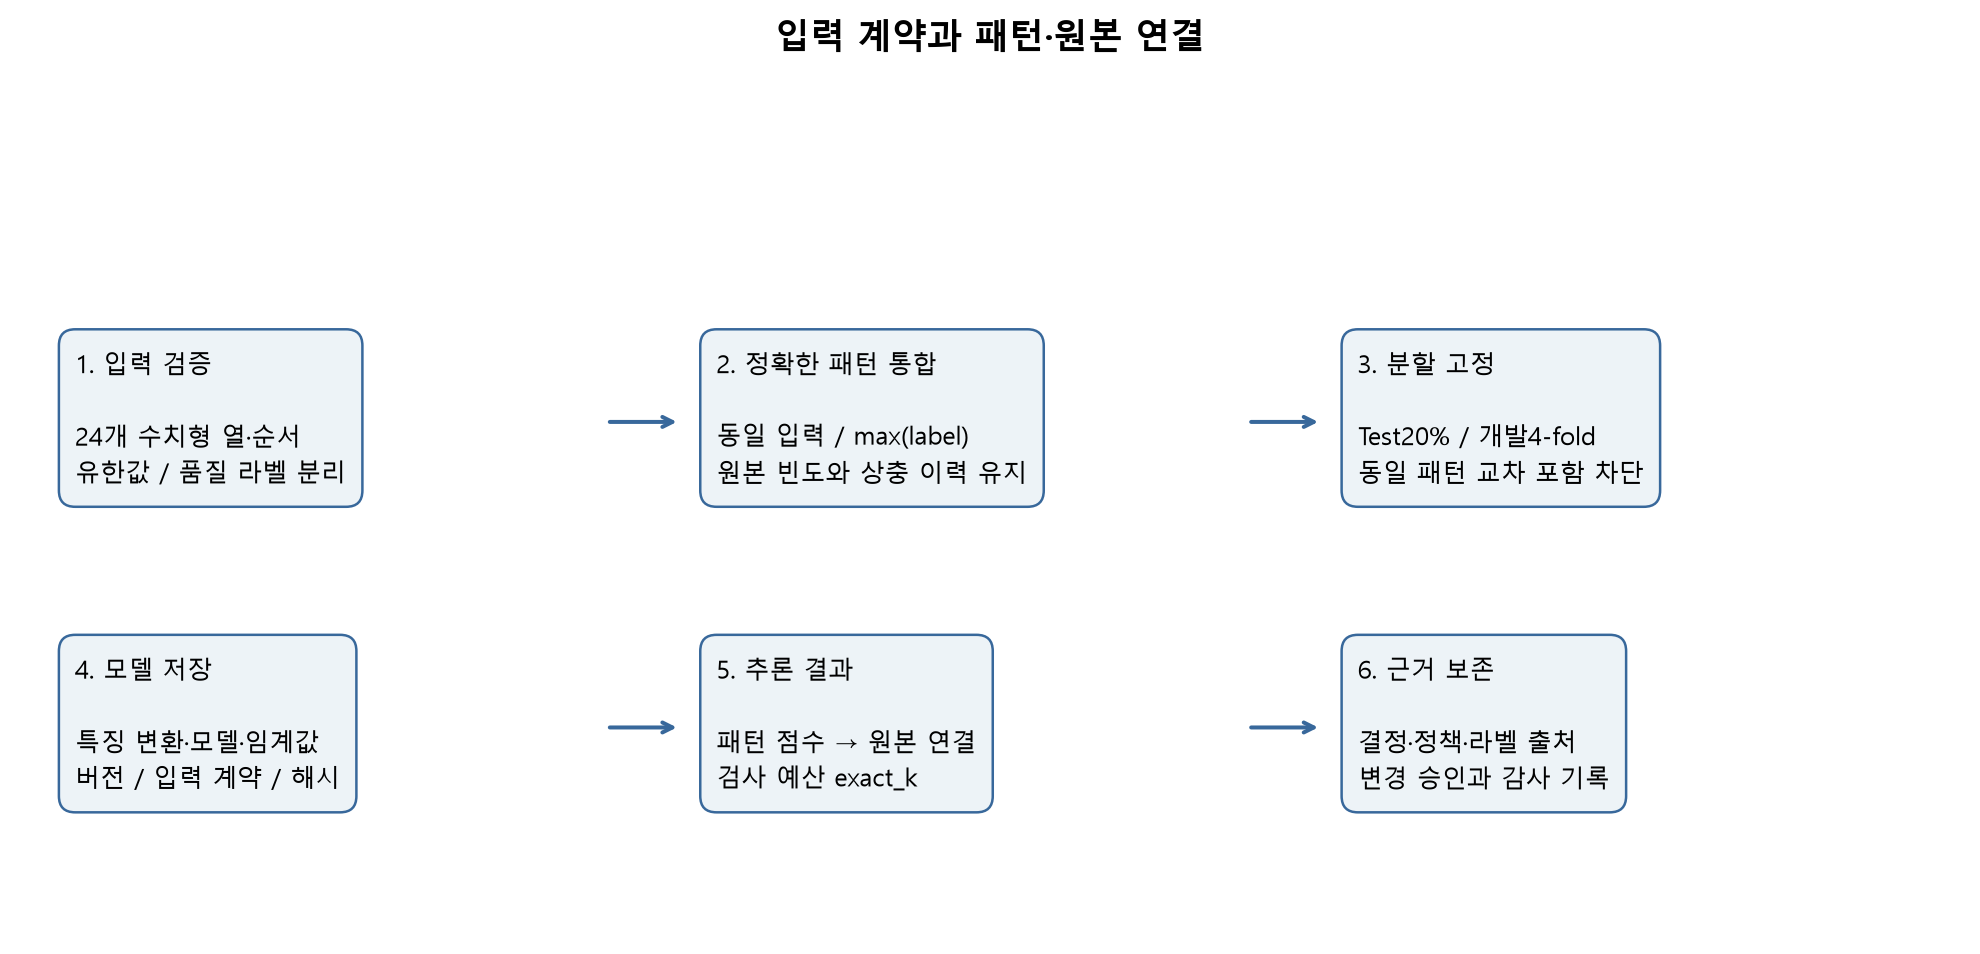

보고서 수록 그림: core_data_contract


In [5]:
# 보고서용 시각화: 기존 학습 셀을 실행하지 않고 저장 결과를 표시한다.
from pathlib import Path
import sys
_report_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / "reporting/visualizations.py").is_file())
if str(_report_root) not in sys.path:
    sys.path.insert(0, str(_report_root))
from reporting.visualizations import show_notebook
_report_figure_ids = show_notebook('03.modeling/common/00_pipeline_core.ipynb')
print("보고서 수록 그림:", ", ".join(_report_figure_ids))
